# Flight Price Prediction using Machine Learning

## Predictive Analytics Using Historical Flight Fare Data

### Project Objective

The objective of this project is to develop a machine learning model that accurately predicts airline ticket prices using historical flight booking data.

This project demonstrates the complete predictive analytics workflow, including:

- Data Collection
- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Model Development
- Model Evaluation
- Prediction and Visualization

### Problem Statement

Flight ticket prices fluctuate due to several factors such as airline, journey date, departure time, arrival time, route, duration, and number of stops. The goal is to analyze historical flight data and build a predictive model capable of estimating ticket prices for future flights.

### Dataset Information

Source : Kaggle

Training Dataset : Data_Train.xlsx

Testing Dataset : Test_set.xlsx

Target Variable : Price

Machine Learning Task : Regression

In [265]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [266]:
df = pd.read_excel("D:/Intern Projects/Flight Fare Prediction/Data_Train.xlsx")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


Display the First Five Rows

In [267]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [268]:
#Display Last Five Rows

In [269]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [270]:
#Dataset Shape

In [271]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 10683
Number of Columns : 11


In [272]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [273]:
#Dataset Information

In [274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [275]:
#Statistical Summary

In [276]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [277]:
#Check Data Types

In [278]:
df.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [279]:
#Check Missing Values

In [280]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [281]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

Route              1
Total_Stops        1
Airline            0
Source             0
Date_of_Journey    0
Dep_Time           0
Destination        0
Arrival_Time       0
Duration           0
Additional_Info    0
Price              0
dtype: int64

In [282]:
#Visualize Missing Values

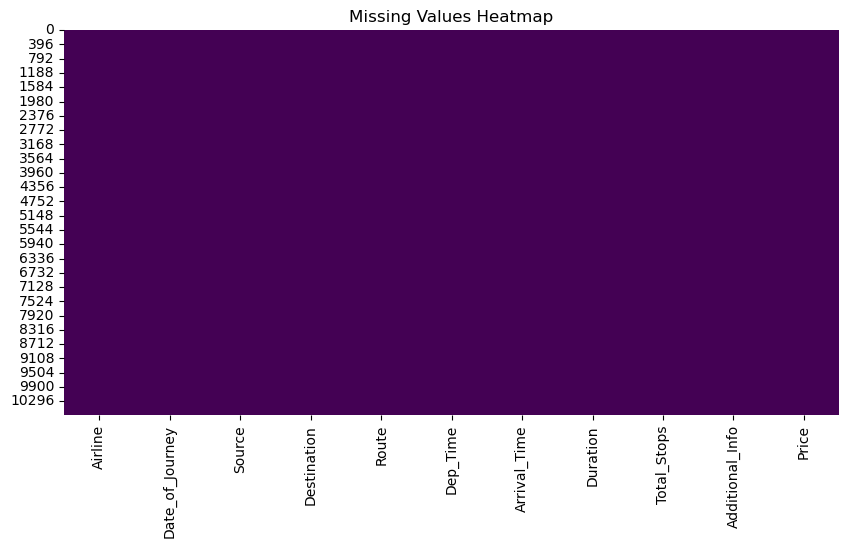

In [283]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

In [284]:
#Check Duplicate Record

In [285]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 220


In [286]:
#Remove Duplicate Rows

In [287]:
df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully!")

Duplicates Removed Successfully!


In [288]:
df.shape

(10463, 11)

In [289]:
#Unique Values in Each Column

In [290]:
for column in df.columns:
    print(f"{column} : {df[column].nunique()} unique values")

Airline : 12 unique values
Date_of_Journey : 44 unique values
Source : 5 unique values
Destination : 6 unique values
Route : 128 unique values
Dep_Time : 222 unique values
Arrival_Time : 1343 unique values
Duration : 368 unique values
Total_Stops : 5 unique values
Additional_Info : 10 unique values
Price : 1870 unique values


In [291]:
#Display Unique Categories

In [292]:
df["Airline"].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [293]:
#Source

In [294]:
df["Source"].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [295]:
#Destination

In [296]:
df["Destination"].unique()

array(['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad'],
      dtype=object)

In [297]:
#Total Stops

In [298]:
df["Total_Stops"].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [299]:
#Dataset Summary Report

In [300]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Unique Values
Airline,object,0,12
Date_of_Journey,object,0,44
Source,object,0,5
Destination,object,0,6
Route,object,1,128
Dep_Time,object,0,222
Arrival_Time,object,0,1343
Duration,object,0,368
Total_Stops,object,1,5
Additional_Info,object,0,10


Data Cleaning

In [301]:
#Check Missing Values


In [302]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [303]:
#Remove Missing Values

In [304]:
df.dropna(inplace=True)
print("Missing Values Removed Successfully!")

df.isnull().sum()

Missing Values Removed Successfully!


Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [305]:
#Convert Date Column

In [306]:
df["Journey_Day"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.day

df["Journey_Month"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.month

df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3


In [307]:
df.drop("Date_of_Journey", axis=1, inplace=True)

In [308]:
#Departure Time

In [309]:
df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour
df["Dep_Min"] = pd.to_datetime(df["Dep_Time"]).dt.minute
df.drop("Dep_Time", axis=1, inplace=True)

In [310]:
#Arrival Time

In [311]:
df["Arrival_Hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour

df["Arrival_Min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

df.drop("Arrival_Time", axis=1, inplace=True)

In [312]:
#Duration

In [313]:
duration = df["Duration"].astype(str)

duration = duration.str.replace(" ", "")

duration

0        2h50m
1        7h25m
2          19h
3        5h25m
4        4h45m
         ...  
10678    2h30m
10679    2h35m
10680       3h
10681    2h40m
10682    8h20m
Name: Duration, Length: 10462, dtype: object

In [314]:
duration = duration.apply(lambda x: x if "h" in x else "0h"+x)

duration = duration.apply(lambda x: x if "m" in x else x+"0m")

In [315]:
df["Duration_Hours"] = duration.str.extract(r'(\d+)h').astype(int)

In [316]:
df["Duration_Minutes"] = duration.str.extract(r'(\d+)m').astype(int)

In [317]:
df.drop("Duration", axis=1, inplace=True)

In [318]:
#Convert Total Stops

In [319]:
df["Total_Stops"] = df["Total_Stops"].map({
    "non-stop":0,
    "1 stop":1,
    "2 stops":2,
    "3 stops":3,
    "4 stops":4
})

df["Total_Stops"].head()

0    0
1    2
2    2
3    1
4    1
Name: Total_Stops, dtype: int64

In [320]:
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hours,Duration_Minutes
0,IndiGo,Banglore,New Delhi,BLR → DEL,0,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1,No info,13302,1,3,16,50,21,35,4,45


In [321]:
#Distribution of Flight Prices

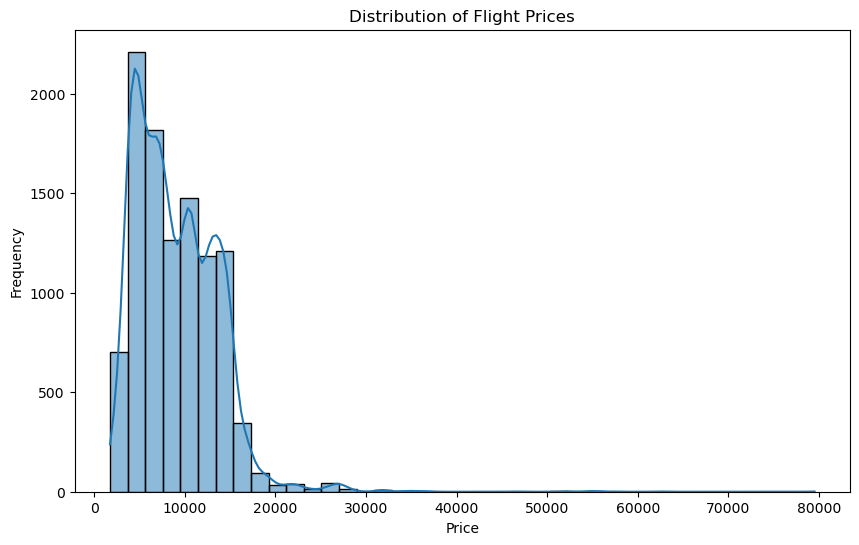

In [322]:
plt.figure(figsize=(10,6))

sns.histplot(df["Price"], bins=40, kde=True)

plt.title("Distribution of Flight Prices")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

### Observation

Most flight prices are concentrated between ₹4,000 and ₹10,000.

The dataset is positively skewed, indicating the presence of a few expensive flights.

In [323]:
#Airline Distribution

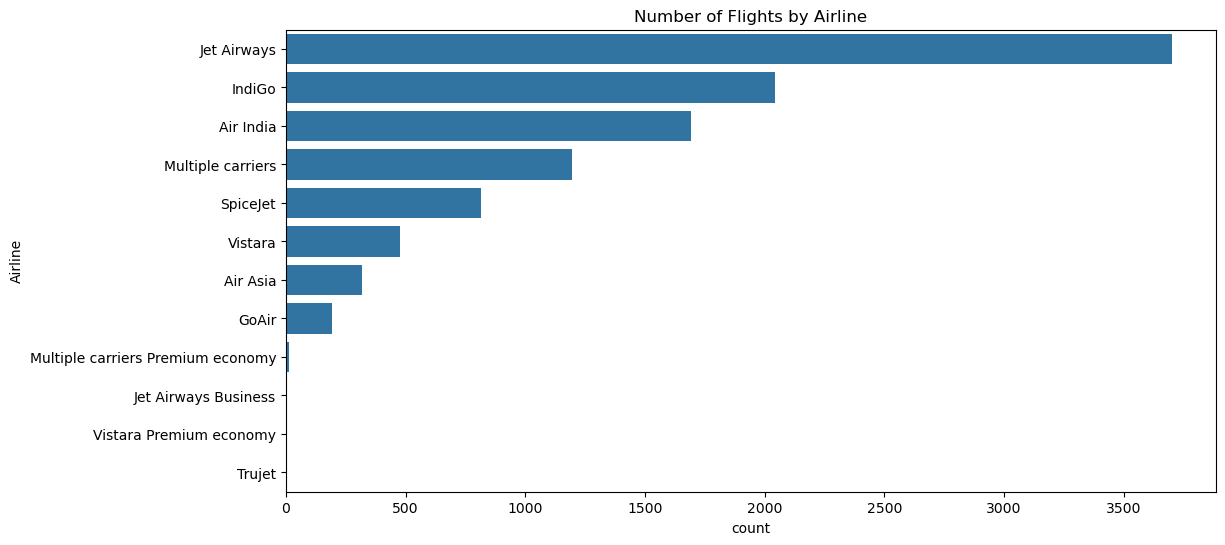

In [324]:
plt.figure(figsize=(12,6))

sns.countplot(y=df["Airline"], order=df["Airline"].value_counts().index)

plt.title("Number of Flights by Airline")

plt.show()

IndiGo operates the highest number of flights in the dataset, followed by Jet Airways and Air India.

In [325]:
#Airline vs Ticket Price

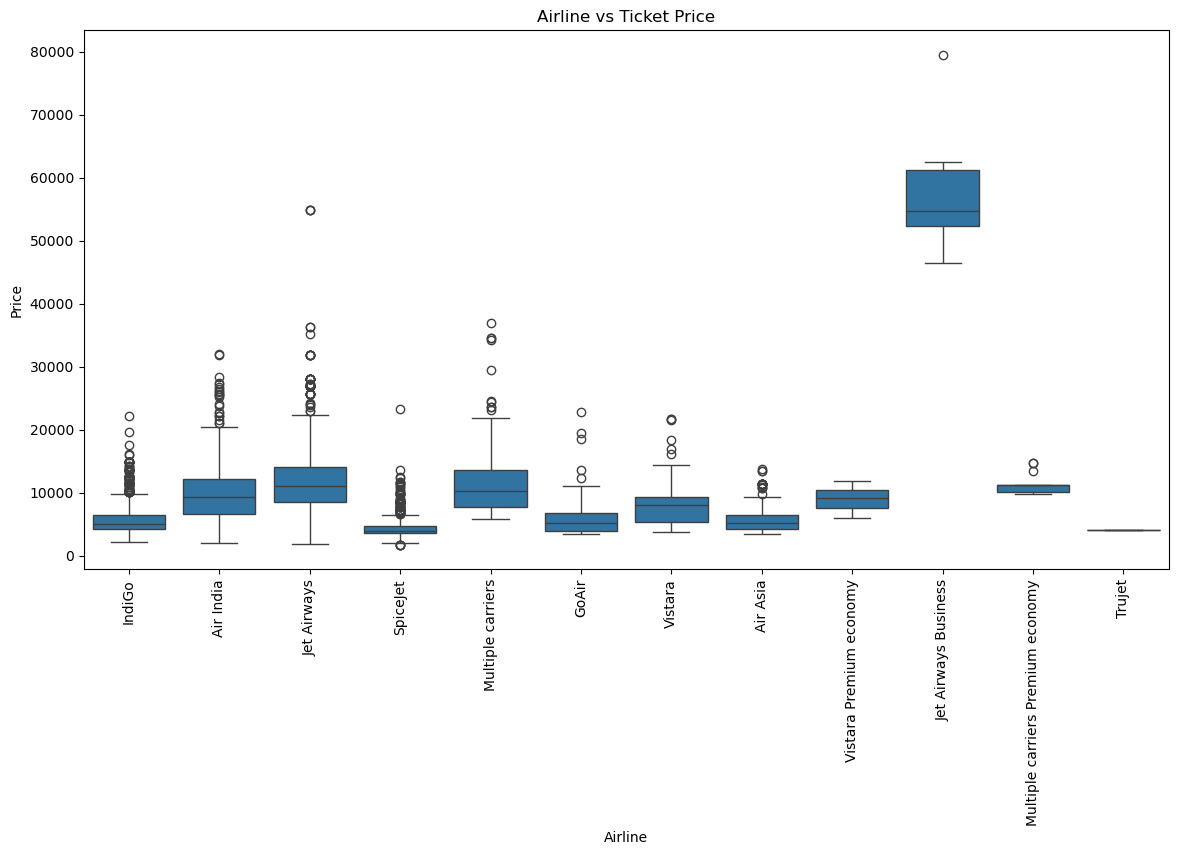

In [326]:
plt.figure(figsize=(14,7))

sns.boxplot(x="Airline", y="Price", data=df)

plt.xticks(rotation=90)

plt.title("Airline vs Ticket Price")

plt.show()

Jet Airways Business has the highest median ticket prices, whereas IndiGo and SpiceJet generally offer lower fares.

In [327]:
#Source Airport Distribution

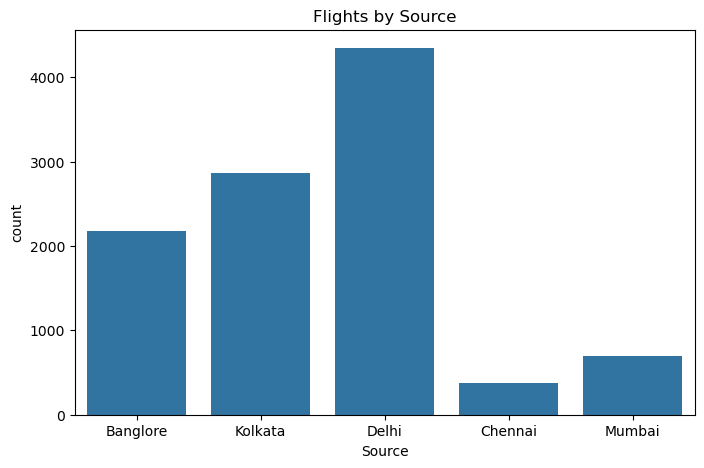

In [328]:
plt.figure(figsize=(8,5))

sns.countplot(x="Source", data=df)

plt.title("Flights by Source")

plt.show()

In [329]:
#Destination Distribution

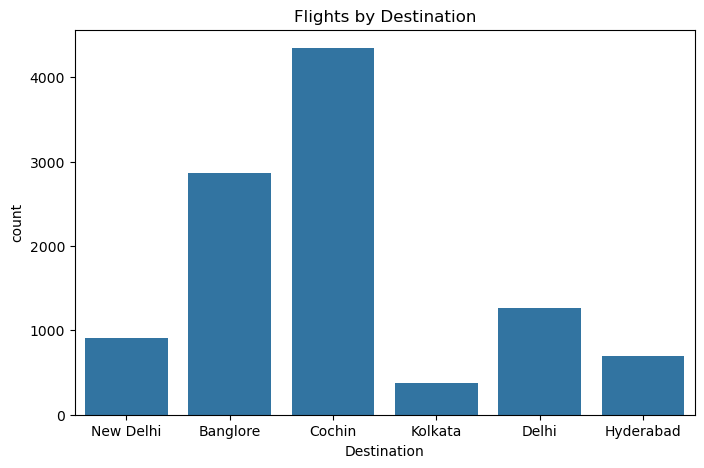

In [330]:
plt.figure(figsize=(8,5))

sns.countplot(x="Destination", data=df)

plt.title("Flights by Destination")

plt.show()

In [331]:
#Total Stops Distribution

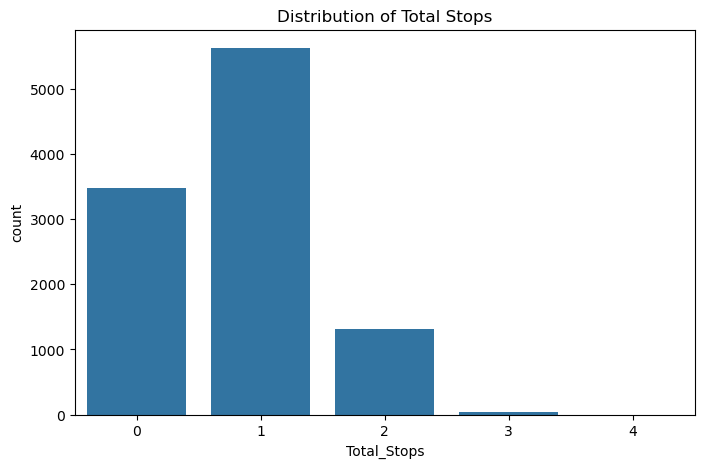

In [332]:
plt.figure(figsize=(8,5))

sns.countplot(x="Total_Stops", data=df)

plt.title("Distribution of Total Stops")

plt.show()

In [333]:
#Stops vs Price

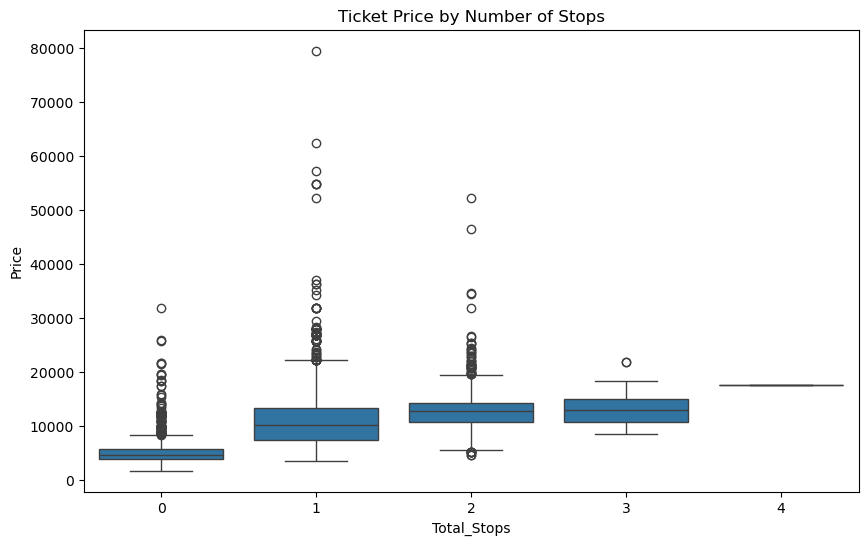

In [334]:
plt.figure(figsize=(10,6))

sns.boxplot(x="Total_Stops", y="Price", data=df)

plt.title("Ticket Price by Number of Stops")

plt.show()

Flights with more stops generally exhibit a wider range of prices. Non-stop flights often command higher fares due to convenience, while multi-stop flights may vary based on airline and route.

In [335]:
#Journey Month

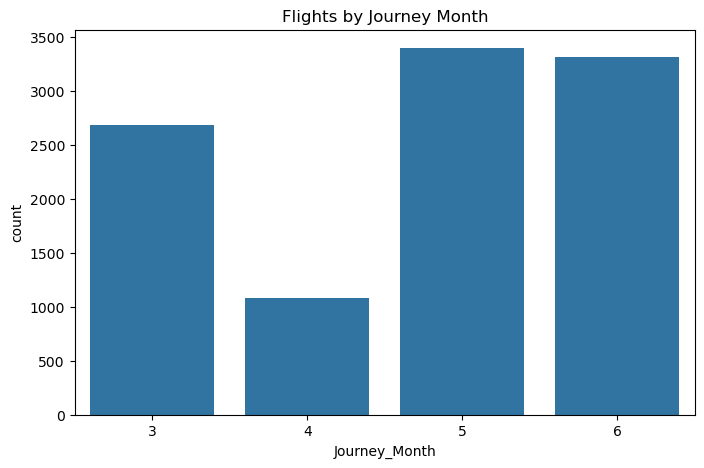

In [336]:
plt.figure(figsize=(8,5))

sns.countplot(x="Journey_Month", data=df)

plt.title("Flights by Journey Month")

plt.show()

In [337]:
#Price vs Journey Month

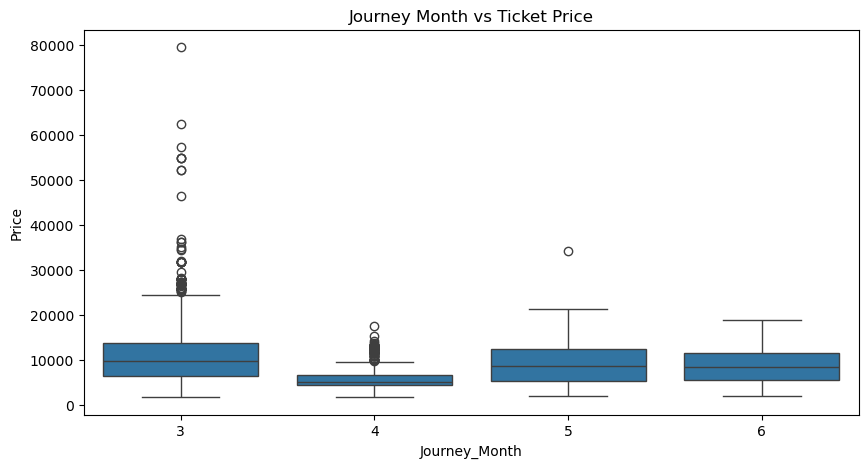

In [338]:
plt.figure(figsize=(10,5))

sns.boxplot(x="Journey_Month", y="Price", data=df)

plt.title("Journey Month vs Ticket Price")

plt.show()

In [339]:
#Correlation Heatmap

In [340]:
numeric_df = df.select_dtypes(include=np.number)

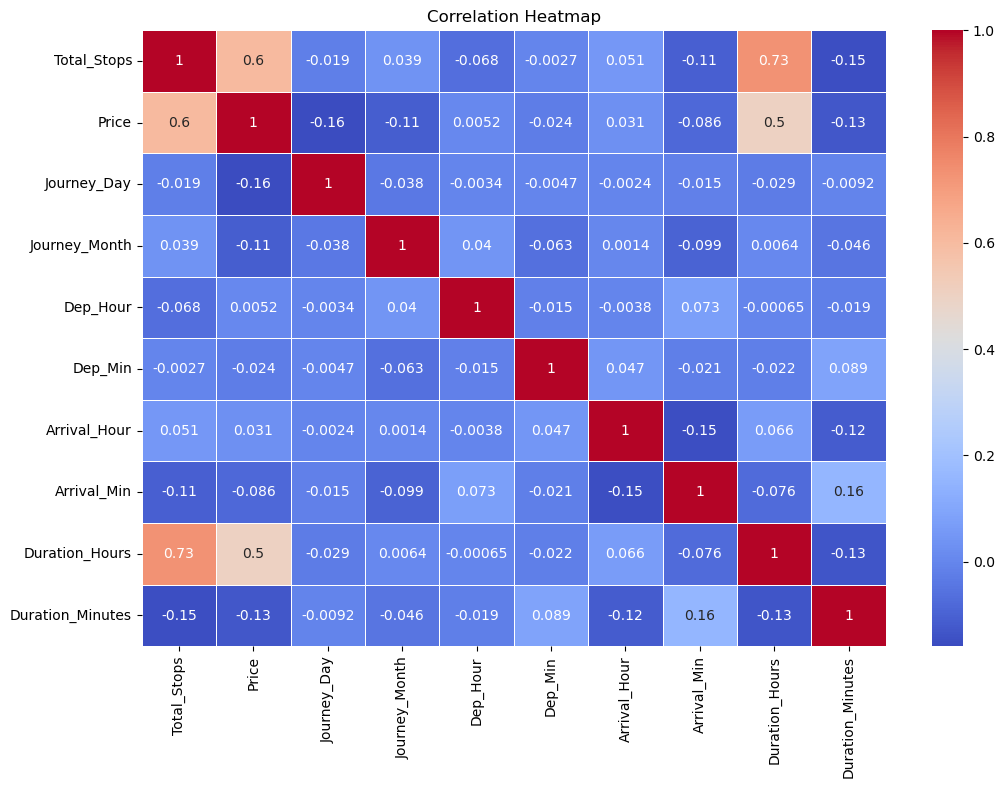

In [341]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [342]:
#Save the Cleaned Dataset

In [343]:
df.to_csv("Cleaned_Flight_Data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [344]:
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hours,Duration_Minutes
0,IndiGo,Banglore,New Delhi,BLR → DEL,0,No info,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2,No info,7662,1,5,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2,No info,13882,9,6,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1,No info,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1,No info,13302,1,3,16,50,21,35,4,45


In [345]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Airline           10462 non-null  object
 1   Source            10462 non-null  object
 2   Destination       10462 non-null  object
 3   Route             10462 non-null  object
 4   Total_Stops       10462 non-null  int64 
 5   Additional_Info   10462 non-null  object
 6   Price             10462 non-null  int64 
 7   Journey_Day       10462 non-null  int32 
 8   Journey_Month     10462 non-null  int32 
 9   Dep_Hour          10462 non-null  int32 
 10  Dep_Min           10462 non-null  int32 
 11  Arrival_Hour      10462 non-null  int32 
 12  Arrival_Min       10462 non-null  int32 
 13  Duration_Hours    10462 non-null  int64 
 14  Duration_Minutes  10462 non-null  int64 
dtypes: int32(6), int64(4), object(5)
memory usage: 1.0+ MB


In [346]:
categorical_columns = [
    "Airline",
    "Source",
    "Destination",
    "Route",
    "Additional_Info"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("One-Hot Encoding Completed Successfully!")

One-Hot Encoding Completed Successfully!


In [347]:
#Check Encoded Dataset

In [348]:
df.head()

,Total_Stops,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hours,Duration_Minutes,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Route_BLR → BBI → DEL,Route_BLR → BDQ → DEL,Route_BLR → BOM → AMD → DEL,Route_BLR → BOM → BHO → DEL,Route_BLR → BOM → DEL,Route_BLR → BOM → IDR → DEL,Route_BLR → BOM → IDR → GWL → DEL,Route_BLR → BOM → IXC → DEL,Route_BLR → BOM → JDH → DEL,Route_BLR → BOM → NAG → DEL,Route_BLR → BOM → UDR → DEL,Route_BLR → CCU → BBI → DEL,Route_BLR → CCU → BBI → HYD → DEL,Route_BLR → CCU → BBI → HYD → VGA → DEL,Route_BLR → CCU → DEL,Route_BLR → CCU → GAU → DEL,Route_BLR → COK → DEL,Route_BLR → DEL,Route_BLR → GAU → DEL,Route_BLR → GOI → DEL,Route_BLR → HBX → BOM → AMD → DEL,Route_BLR → HBX → BOM → BHO → DEL,Route_BLR → HBX → BOM → NAG → DEL,Route_BLR → HYD → DEL,Route_BLR → HYD → VGA → DEL,Route_BLR → IDR → DEL,Route_BLR → LKO → DEL,Route_BLR → MAA → DEL,Route_BLR → NAG → DEL,Route_BLR → PNQ → DEL,Route_BLR → STV → DEL,Route_BLR → TRV → COK → DEL,Route_BLR → VGA → DEL,Route_BLR → VGA → HYD → DEL,Route_BLR → VGA → VTZ → DEL,Route_BOM → AMD → ISK → HYD,Route_BOM → BBI → HYD,Route_BOM → BDQ → DEL → HYD,Route_BOM → BHO → DEL → HYD,Route_BOM → BLR → CCU → BBI → HYD,Route_BOM → BLR → HYD,Route_BOM → CCU → HYD,Route_BOM → COK → MAA → HYD,Route_BOM → DED → DEL → HYD,Route_BOM → DEL → HYD,Route_BOM → GOI → HYD,Route_BOM → GOI → PNQ → HYD,Route_BOM → HYD,Route_BOM → IDR → DEL → HYD,Route_BOM → JAI → DEL → HYD,Route_BOM → JDH → DEL → HYD,Route_BOM → JDH → JAI → DEL → HYD,Route_BOM → JLR → HYD,Route_BOM → MAA → HYD,Route_BOM → NDC → HYD,Route_BOM → RPR → VTZ → HYD,Route_BOM → UDR → DEL → HYD,Route_BOM → VNS → DEL → HYD,Route_CCU → AMD → BLR,Route_CCU → BBI → BLR,Route_CCU → BBI → BOM → BLR,Route_CCU → BBI → HYD → BLR,Route_CCU → BBI → IXR → DEL → BLR,Route_CCU → BLR,Route_CCU → BOM → AMD → BLR,Route_CCU → BOM → BLR,Route_CCU → BOM → COK → BLR,Route_CCU → BOM → GOI → BLR,Route_CCU → BOM → HBX → BLR,Route_CCU → BOM → PNQ → BLR,Route_CCU → BOM → TRV → BLR,Route_CCU → DEL → AMD → BLR,Route_CCU → DEL → BLR,Route_CCU → DEL → COK → BLR,Route_CCU → DEL → COK → TRV → BLR,Route_CCU → DEL → VGA → BLR,Route_CCU → GAU → BLR,Route_CCU → GAU → DEL → BLR,Route_CCU → GAU → IMF → DEL → BLR,Route_CCU → HYD → BLR,Route_CCU → IXA → BLR,Route_CCU → IXB → BLR,Route_CCU → IXB → DEL → BLR,Route_CCU → IXR → BBI → BLR,Route_CCU → IXR → DEL → BLR,Route_CCU → IXZ → MAA → BLR,Route_CCU → JAI → BOM → BLR,Route_CCU → JAI → DEL → BLR,Route_CCU → KNU → BLR,Route_CCU → MAA → BLR,Route_CCU → NAG → BLR,Route_CCU → PAT → BLR,Route_CCU → PNQ → BLR,Route_CCU → RPR → HYD → BLR,Route_CCU → VNS → DEL → BLR,Route_CCU → VTZ → BLR,Route_DEL → AMD → BOM → COK,Route_DEL → AMD → COK,Route_DEL → ATQ → BOM → COK,Route_DEL → BBI → COK,Route_DEL → BDQ → BOM → COK,Route_DEL → BHO → BOM → COK,Route_DEL → BLR → COK,Route_DEL → BOM → COK,Route_DEL → CCU → BOM → COK,Route_DEL → COK,Route_DEL → DED → BOM → COK,Route_DEL → GOI → BOM → COK,Route_DEL → GWL → IDR → BOM → COK,Route_DEL → HYD → BOM → COK,Route_DEL → HYD → COK,Route_DEL → HYD → MAA → COK,Route_DEL → IDR → BOM → COK,Route_DEL → IXC → BOM → COK,Route_DEL → IXU → BOM → COK,Route_DEL → JAI → BOM → COK,Route_DEL → JDH → BOM → COK,Route_DEL → LKO → BOM → COK,Route_DEL → LKO → COK,Route_DEL → MAA → BOM → COK,Route_DEL → MAA → COK,Route_DEL → NAG → BOM → COK,Route_DEL → PNQ → COK,Route_DEL → RPR → NAG → BOM → COK,Route_DEL → TRV → COK,Route_DEL → UDR → BOM → COK,Route_MAA → CCU,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Addit

In [349]:
#Dataset Shape

In [350]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10462, 166)


In [351]:
df.isnull().sum().sum()

np.int64(0)

In [352]:
#Separate Features and Target

In [353]:
X = df.drop("Price", axis=1)

y = df["Price"]

In [354]:
#Display Shapes

In [355]:
print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Matrix Shape : (10462, 165)
Target Shape : (10462,)


In [356]:
#Train-Test Split

In [357]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [358]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (8369, 165)
Testing Features : (2093, 165)
Training Labels : (8369,)
Testing Labels : (2093,)


In [359]:
#Model 1 - Linear Regression

In [360]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [361]:
#Make Predictions

In [362]:
linear_predictions = linear_model.predict(X_test)

In [363]:
#Evaluate Linear Regression

In [364]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, linear_predictions)

mse = mean_squared_error(y_test, linear_predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Performance")

print("-"*40)

print("MAE :", mae)

print("RMSE :", rmse)

print("R² Score :", r2)

Linear Regression Performance
----------------------------------------
MAE : 1543.8107828298562
RMSE : 2436.3529940424723
R² Score : 0.7153123630596543


In [365]:
#Actual vs Predicted Values

In [366]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": linear_predictions
})

results.head(10)

,Actual Price,Predicted Price
0,17996,16745.513212
1,3873,4331.431093
2,4462,4733.451599
3,2228,4123.994593
4,4991,3027.415761
5,7670,11108.822172
6,14086,8916.102256
7,6386,7090.628096
8,6628,9366.124960
9,6934,6127.357233


In [367]:
#Visualization: Actual vs Predicted

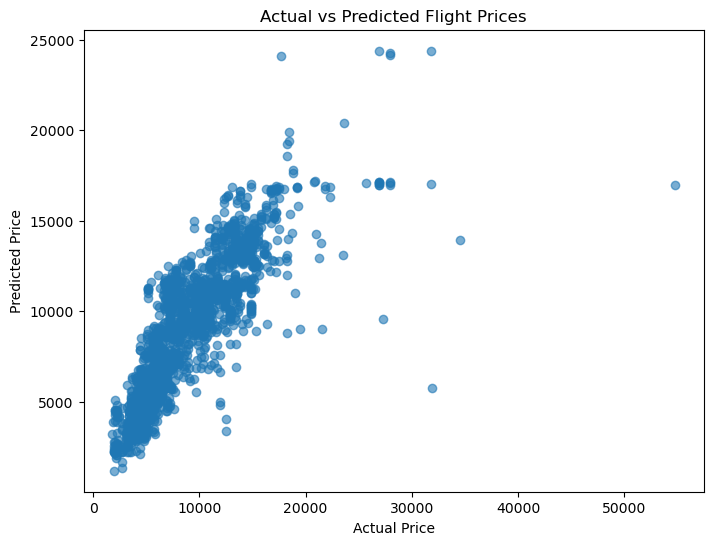

In [368]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, linear_predictions, alpha=0.6)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Flight Prices")

plt.show()

In [369]:
#Visualization: Prediction Error

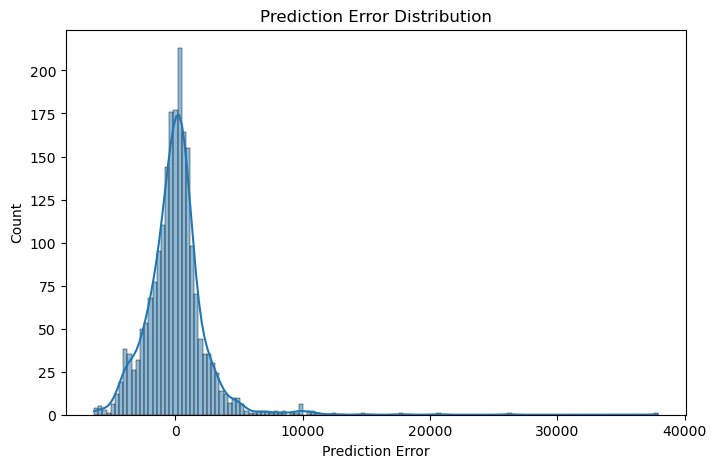

In [370]:
errors = y_test - linear_predictions

plt.figure(figsize=(8,5))

sns.histplot(errors, kde=True)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")

plt.show()

In [371]:
#Decision Tree Regressor

In [372]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [373]:
#Predict using Decision Tree

In [374]:
dt_predictions = dt_model.predict(X_test)

In [375]:
#Evaluate Decision Tree

In [376]:
dt_mae = mean_absolute_error(y_test, dt_predictions)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))

dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Performance")
print("-"*40)

print(f"MAE : {dt_mae:.2f}")
print(f"RMSE : {dt_rmse:.2f}")
print(f"R² Score : {dt_r2:.4f}")

Decision Tree Performance
----------------------------------------
MAE : 705.37
RMSE : 1711.24
R² Score : 0.8596


In [377]:
#Random Forest Regressor

In [378]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [379]:
#Predict using Random Forest

In [380]:
rf_predictions = rf_model.predict(X_test)

In [381]:
#Evaluate Random Forest

In [382]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("-"*40)

print(f"MAE : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R² Score : {rf_r2:.4f}")

Random Forest Performance
----------------------------------------
MAE : 627.94
RMSE : 1418.53
R² Score : 0.9035


In [383]:
#Compare All Models

In [384]:
comparison = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    
    "MAE":[
        mae,
        dt_mae,
        rf_mae
    ],
    
    "RMSE":[
        rmse,
        dt_rmse,
        rf_rmse
    ],
    
    "R2 Score":[
        r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1543.810783,2436.352994,0.715312
1,Decision Tree,705.369645,1711.242230,0.859553
2,Random Forest,627.936022,1418.527557,0.903492


In [385]:
#Sort Models

In [386]:
comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,627.936022,1418.527557,0.903492
1,Decision Tree,705.369645,1711.242230,0.859553
0,Linear Regression,1543.810783,2436.352994,0.715312


In [387]:
#Visualization: Model Comparison

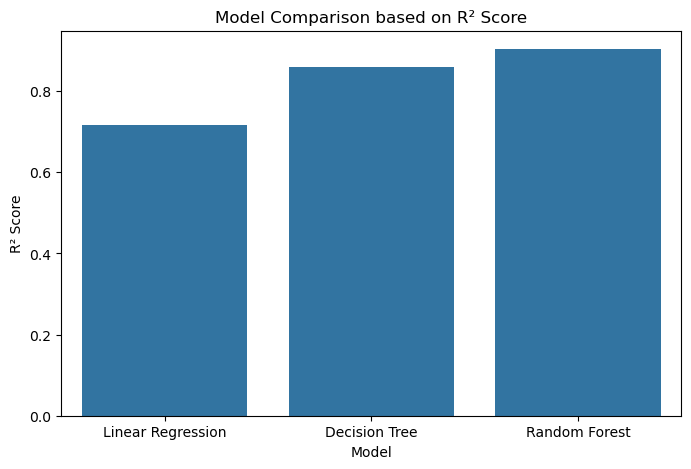

In [388]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison based on R² Score")

plt.ylabel("R² Score")

plt.show()

In [389]:
#Actual vs Predicted

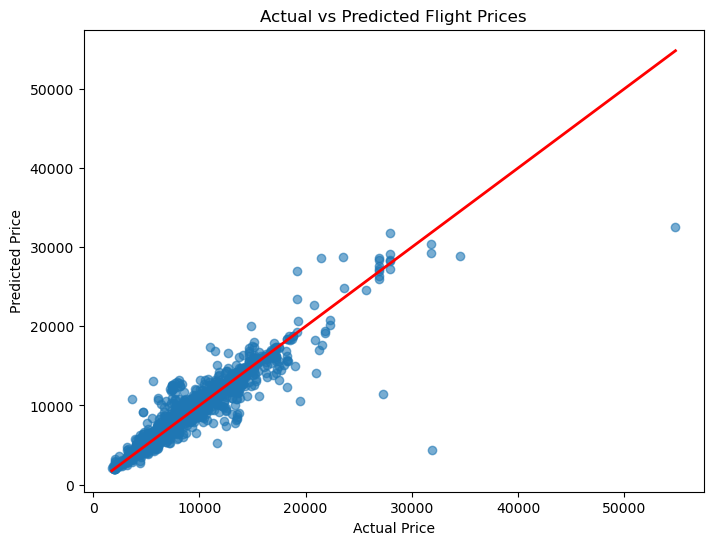

In [390]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Flight Prices")

plt.show()

In [391]:
#Residual Plot

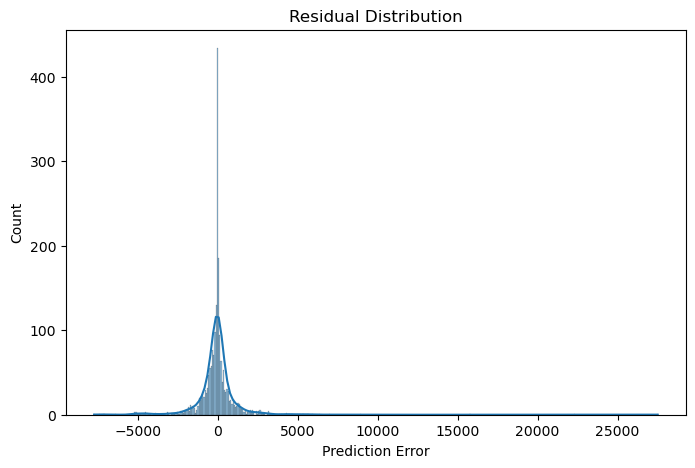

In [392]:
residuals = y_test - rf_predictions

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

In [393]:
#Feature Importance

In [394]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
7,Duration_Hours,0.415859
1,Journey_Day,0.095734
160,Additional_Info_In-flight meal not included,0.077084
13,Airline_Jet Airways Business,0.066724
12,Airline_Jet Airways,0.063477
2,Journey_Month,0.046884
0,Total_Stops,0.024465
28,Destination_New Delhi,0.020758
14,Airline_Multiple carriers,0.018183
5,Arrival_Hour,0.017261


In [395]:
#Plot Feature Importance

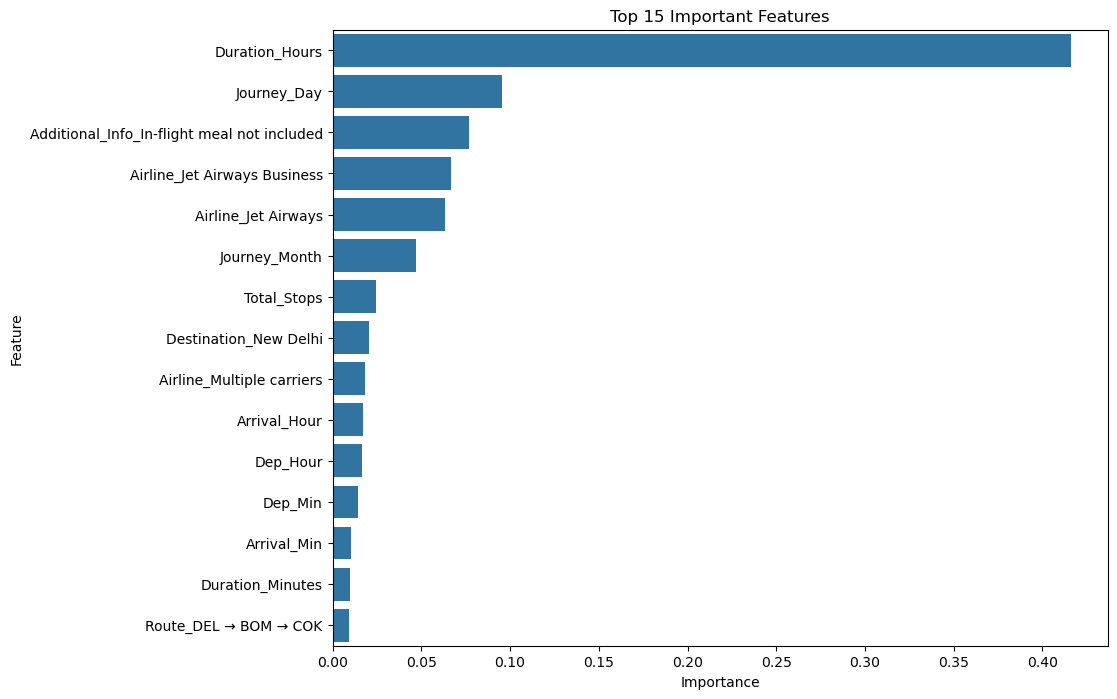

In [396]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

In [397]:
#Save Best Model

In [398]:
import joblib

joblib.dump(
    rf_model,
    "Flight_Price_Prediction_Model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [399]:
#Save Feature List

In [400]:
joblib.dump(
    X.columns.tolist(),
    "Model_Features.pkl"
)

print("Feature List Saved Successfully!")

Feature List Saved Successfully!


In [401]:
#Load the Test Dataset

In [402]:
test_df = pd.read_excel("D:/Intern Projects/Flight Fare Prediction/Test_set.xlsx")

print("Test Dataset Loaded Successfully!")

Test Dataset Loaded Successfully!


In [403]:
test_df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info


In [404]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          2671 non-null   object
 1   Date_of_Journey  2671 non-null   object
 2   Source           2671 non-null   object
 3   Destination      2671 non-null   object
 4   Route            2671 non-null   object
 5   Dep_Time         2671 non-null   object
 6   Arrival_Time     2671 non-null   object
 7   Duration         2671 non-null   object
 8   Total_Stops      2671 non-null   object
 9   Additional_Info  2671 non-null   object
dtypes: object(10)
memory usage: 208.8+ KB


In [405]:
#Handle Missing Values

In [406]:
test_df = test_df.dropna(subset=["Route", "Total_Stops"])

Feature Engineering

In [407]:
#Journey Date

In [408]:
test_df["Journey_Day"] = pd.to_datetime(
    test_df["Date_of_Journey"],
    format="%d/%m/%Y"
).dt.day

test_df["Journey_Month"] = pd.to_datetime(
    test_df["Date_of_Journey"],
    format="%d/%m/%Y"
).dt.month

test_df.drop("Date_of_Journey", axis=1, inplace=True)

In [409]:
#Departure Time

In [410]:
test_df["Dep_Hour"] = pd.to_datetime(test_df["Dep_Time"]).dt.hour

test_df["Dep_Min"] = pd.to_datetime(test_df["Dep_Time"]).dt.minute

test_df.drop("Dep_Time", axis=1, inplace=True)

In [411]:
#Arrival Time

In [412]:
test_df["Arrival_Hour"] = pd.to_datetime(test_df["Arrival_Time"]).dt.hour

test_df["Arrival_Min"] = pd.to_datetime(test_df["Arrival_Time"]).dt.minute

test_df.drop("Arrival_Time", axis=1, inplace=True)

In [413]:
#Duration

In [414]:
duration = test_df["Duration"].astype(str)

duration = duration.str.replace(" ", "")

duration = duration.apply(lambda x: x if "h" in x else "0h"+x)

duration = duration.apply(lambda x: x if "m" in x else x+"0m")

test_df["Duration_Hours"] = duration.str.extract(r'(\d+)h').astype(int)

test_df["Duration_Minutes"] = duration.str.extract(r'(\d+)m').astype(int)

test_df.drop("Duration", axis=1, inplace=True)

In [415]:
#Total Stops

In [416]:
stop_mapping = {
    "non-stop":0,
    "1 stop":1,
    "2 stops":2,
    "3 stops":3,
    "4 stops":4
}

test_df["Total_Stops"] = test_df["Total_Stops"].replace(stop_mapping)

In [417]:
#One-Hot Encoding

In [418]:
categorical_columns = [
    "Airline",
    "Source",
    "Destination",
    "Route",
    "Additional_Info"
]

test_df = pd.get_dummies(
    test_df,
    columns=categorical_columns,
    drop_first=True
)

In [419]:
#Match Training Columns

In [420]:
missing_cols = set(X.columns) - set(test_df.columns)

for col in missing_cols:
    test_df[col] = 0

test_df = test_df[X.columns]

In [421]:
#Predict Flight Prices

In [422]:
predicted_prices = rf_model.predict(test_df)

predicted_prices[:10]

array([14714.        ,  4229.73      , 12898.        , 13481.00583333,
        3757.255     , 10291.925     , 10036.13      ,  5718.19      ,
        4453.385     , 14750.55      ])

In [423]:
#Load Sample Submission

In [424]:
submission = pd.read_excel("D:/Intern Projects/Flight Fare Prediction/Sample_submission.xlsx")

submission.head()

,Price
0,15998
1,16612
2,25572
3,25778
4,16934


In [425]:
#Add Predictions

In [426]:
submission["Price"] = predicted_prices

submission.head()

,Price
0,14714.000000
1,4229.730000
2,12898.000000
3,13481.005833
4,3757.255000


In [427]:
#Save Submission File

In [428]:
submission.to_csv(
    "Flight_Price_Predictions.csv",
    index=False
)

print("Prediction File Saved Successfully!")

Prediction File Saved Successfully!


In [429]:
#Display Sample Predictions

In [430]:
submission.sample(10)

,Price
765,9640.401964
2420,14172.000000
2118,4747.715000
852,7332.325000
780,12002.775000
2057,12430.011750
2626,6732.495000
1312,11825.530000
164,4093.370000
2022,3098.270000


In [431]:
#Final Model Performance Table

In [432]:
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1543.810783,2436.352994,0.715312
1,Decision Tree,705.369645,1711.242230,0.859553
2,Random Forest,627.936022,1418.527557,0.903492


In [433]:
#Save the Final Dataset

In [434]:
df.to_csv(
    "Processed_Flight_Dataset.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [435]:
#Save the Comparison Table

In [436]:
comparison.to_csv(
    "Model_Comparison.csv",
    index=False
)

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1543.810783,2436.352994,0.715312
1,Decision Tree,705.369645,1711.242230,0.859553
2,Random Forest,627.936022,1418.527557,0.903492


In [449]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [461]:
#Ticket Price vs Total Stops

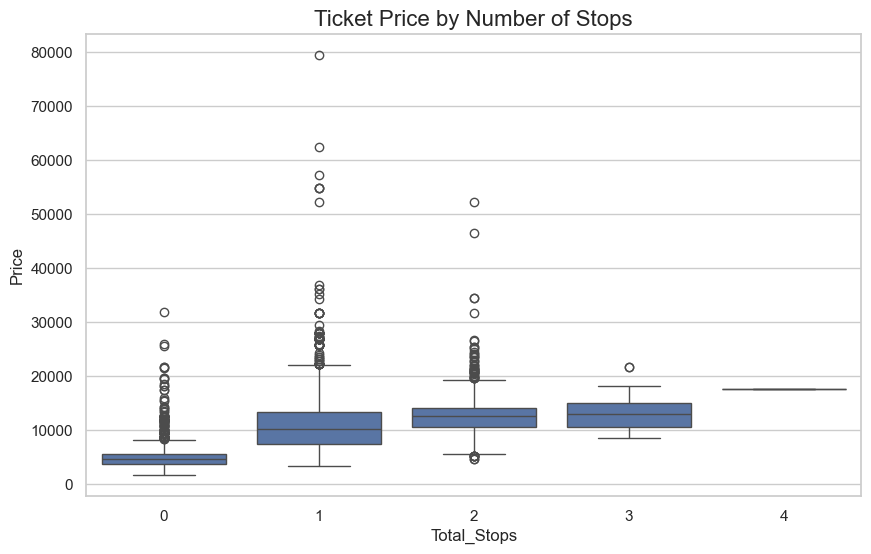

In [462]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Total_Stops",
    y="Price"
)

plt.title("Ticket Price by Number of Stops", fontsize=16)

plt.show()

In [465]:
#Departure Hour Distribution

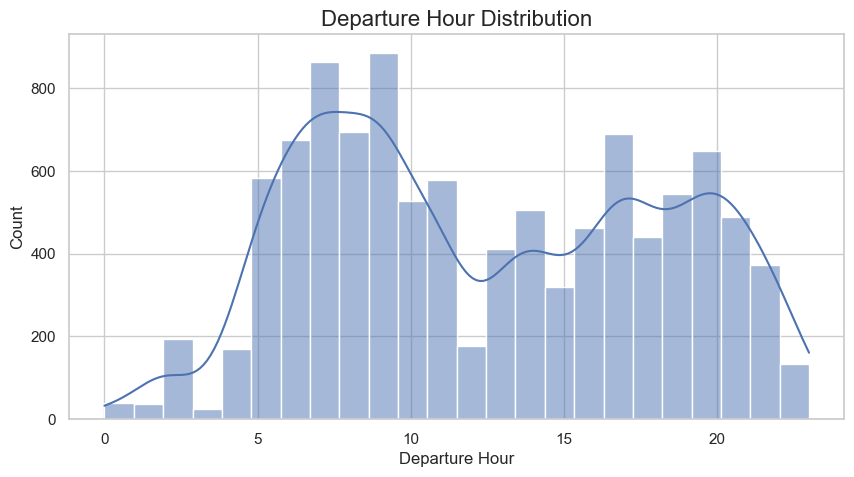

In [468]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Dep_Hour"],
    bins=24,
    kde=True
)

plt.title("Departure Hour Distribution", fontsize=16)

plt.xlabel("Departure Hour")

plt.show()

In [469]:
#Arrival Hour Distribution

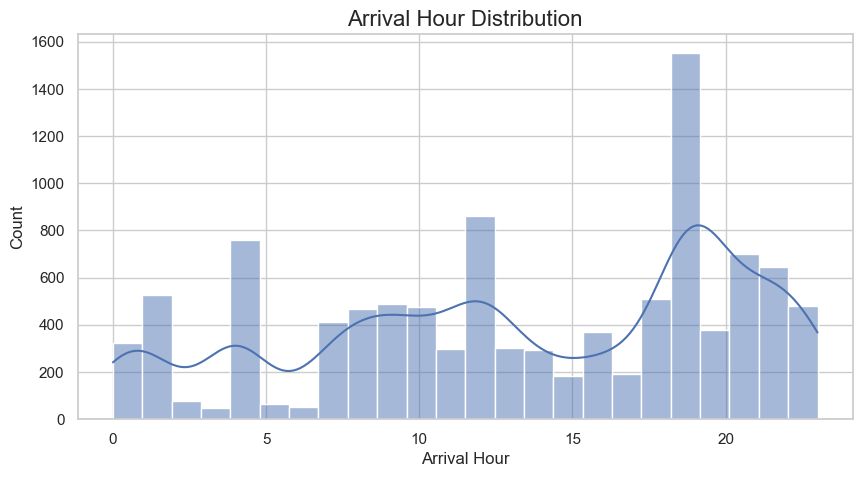

In [470]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Arrival_Hour"],
    bins=24,
    kde=True
)

plt.title("Arrival Hour Distribution", fontsize=16)

plt.xlabel("Arrival Hour")

plt.show()

In [471]:
#Flight Duration Distribution

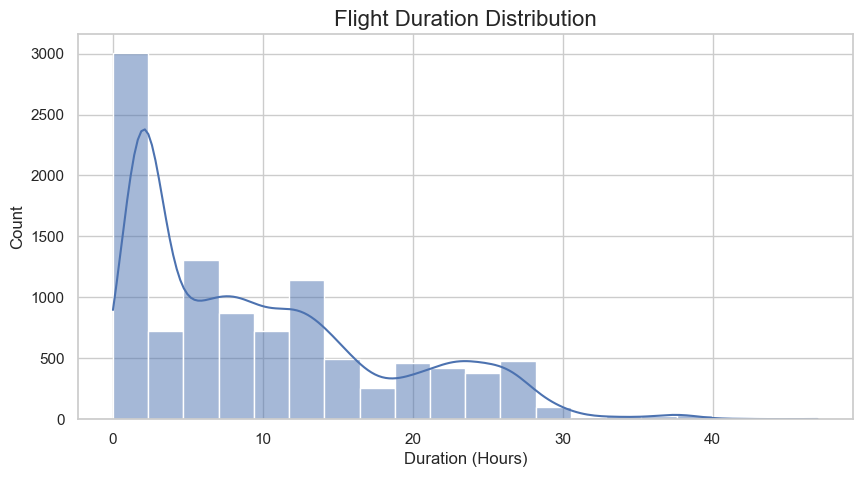

In [472]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Duration_Hours"],
    bins=20,
    kde=True
)

plt.title("Flight Duration Distribution", fontsize=16)

plt.xlabel("Duration (Hours)")

plt.show()

In [473]:
#Flight Duration vs Ticket Price

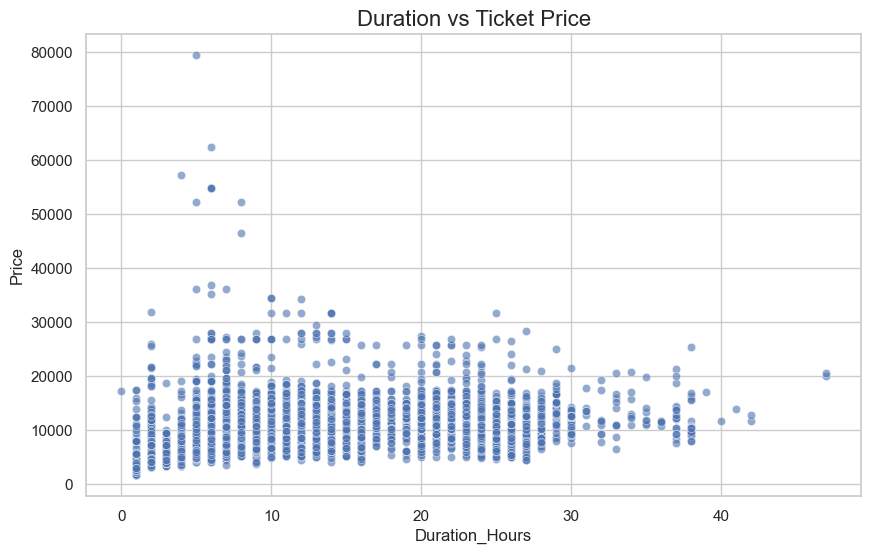

In [474]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Duration_Hours",
    y="Price",
    alpha=0.6
)

plt.title("Duration vs Ticket Price", fontsize=16)

plt.show()

In [477]:
#Ticket Price Outliers

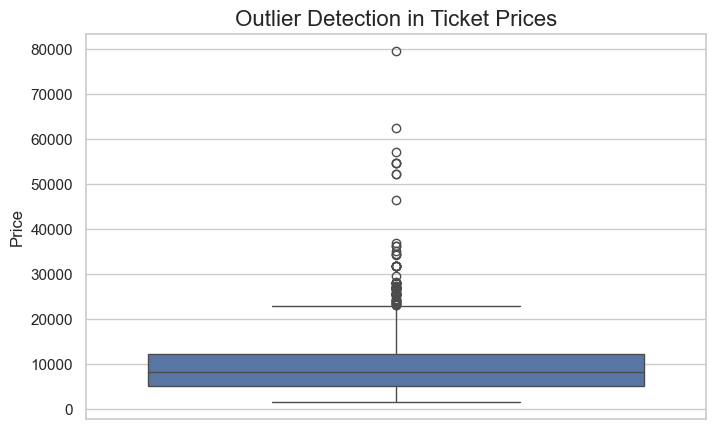

In [478]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["Price"]
)

plt.title("Outlier Detection in Ticket Prices", fontsize=16)

plt.show()

In [479]:
#Pair Plot

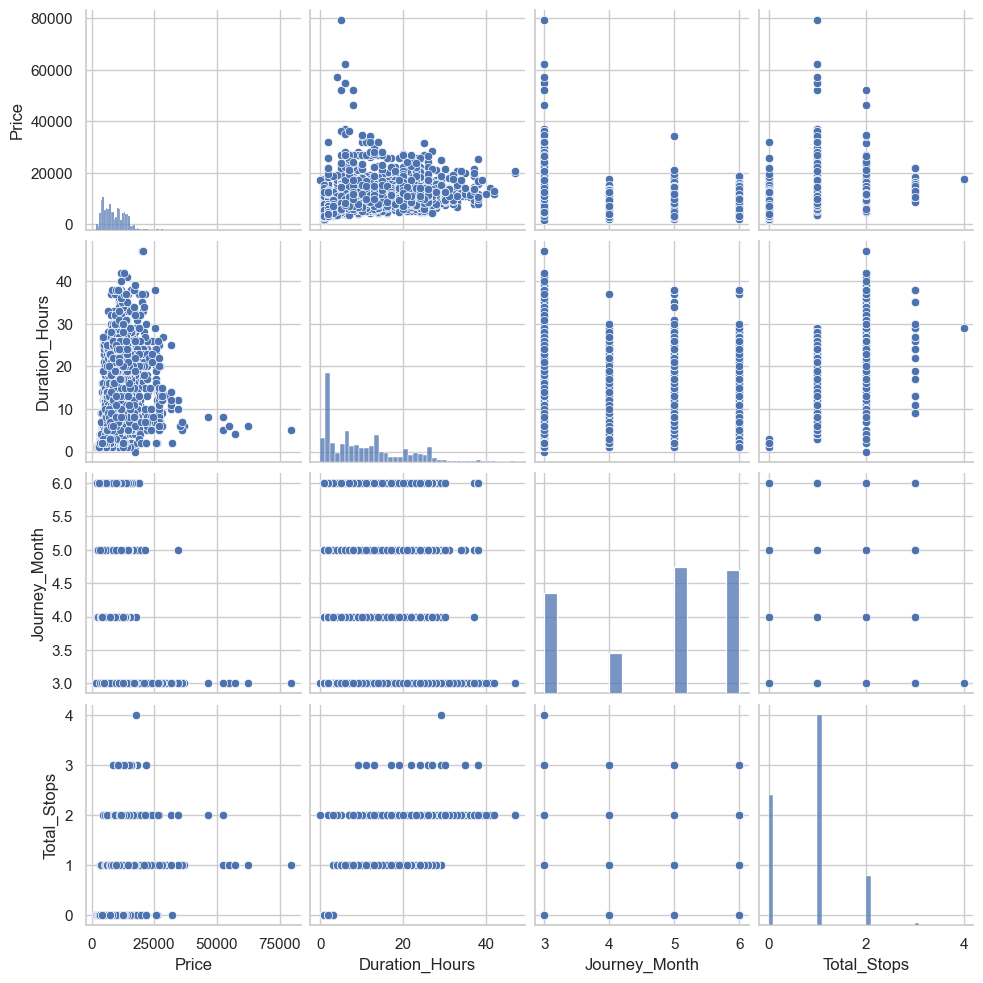

In [480]:
sns.pairplot(
    df[
        [
            "Price",
            "Duration_Hours",
            "Journey_Month",
            "Total_Stops"
        ]
    ]
)

plt.show()

# Conclusion

## Project Summary

The objective of this project was to develop a predictive analytics model capable of estimating flight ticket prices using historical airline booking data. A complete machine learning workflow was implemented, including data preprocessing, feature engineering, exploratory data analysis (EDA), model training, evaluation, and prediction.

The dataset was thoroughly cleaned by handling missing values, removing duplicate records, extracting useful information from date and time features, and converting categorical variables into machine-learning-compatible formats. Exploratory Data Analysis provided valuable insights into the factors affecting flight prices, such as airline, number of stops, flight duration, source, destination, and journey month.

Three regression algorithms—Linear Regression, Decision Tree Regressor, and Random Forest Regressor—were trained and evaluated using MAE, RMSE, and R² Score. Among these models, the **Random Forest Regressor** delivered the best predictive performance, demonstrating its ability to capture complex relationships within the data and produce accurate fare predictions.

Overall, this project successfully demonstrates the application of predictive analytics and machine learning techniques to solve a real-world business problem. The developed model can support airlines, travel agencies, and customers by providing reliable flight fare predictions, enabling better planning and data-driven decision-making. Future improvements may include hyperparameter tuning, advanced ensemble models such as XGBoost or LightGBM, and deployment as a web application for real-time flight price prediction.